Following the data and simulation files processing, here we:

- **Merge** processed files by production conditions. For HE calibration, we need first to merge per LDC before merging per run.
- Perform **S1-based cuts**.
- **Tag** global events by type of particle (electron or alpha-like) and detector region.
- **Store** final HDF5 merged file for subsequent analysis.
- **Update** the corresponding summary.

In [2]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import crudo

from datetime import datetime
import glob
from IPython.core.magic import register_cell_magic
import matplotlib.pyplot as plt
import os
import pandas as pd
from pathlib import Path
import numpy as np
import yaml

# Styling Plot
crudo.pt.ccortesp_plot_style()

%matplotlib inline
%load_ext autoreload
%autoreload 2

@register_cell_magic
def skip_if(line, cell):
    """Skips execution of the cell if the expression evaluates to True."""
    if eval(line, get_ipython().user_ns):
        print(f"⏭️ Cell skipped: condition '{line}' is True")
        return
    exec(cell, get_ipython().user_ns)

# Configuration

In [6]:
FILE_TAG = 'radiogenics_lpr_v2'     # Options: 'radiogenics_hpr', 'radiogenics_lpr', 'bb2nu_hpr', 'bb2nu_lpr', 'bb0nu_hpr', 'bb0nu_lpr'
TYPE = 'data'                       # Options: 'data', 'mc'
EXTRA = 'icaros'                        # Options: 'icaros', 'feedthrough', etc 

# ------------------
# LOAD CONFIGURATION
# ------------------
if 'radiogenics' in FILE_TAG   : CONFIG_FILE = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Universal/configs/low_bckg_analysis_config.yaml'
elif 'calibration' in FILE_TAG : CONFIG_FILE = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Universal/configs/he_analysis_config.yaml' 

try:
    with open(CONFIG_FILE, 'r') as f:
        all_configs = yaml.safe_load(f)
except FileNotFoundError:
    raise FileNotFoundError(f"Configuration file '{CONFIG_FILE}' not found. Please check the path and try again.")

if FILE_TAG not in all_configs:
    raise ValueError(f"Version tag '{FILE_TAG}' not found in the configuration file. Available tags: {list(all_configs.keys())}")

# Set up the configuration
common_config = all_configs['common']
ana_config    = all_configs[FILE_TAG]
ana_type      = TYPE + '_' + EXTRA if EXTRA is not None else TYPE
print(f"{'-'*5} Loading configuration for {ana_type.upper()}")

# --- Directories
FILE_DIR = common_config['file_dir']
PROC_DATA_DIR = os.path.join(FILE_DIR, 'runs') if TYPE == 'data' else None
PROC_MC_DIR   = os.path.join(FILE_DIR, 'mc')   if TYPE == 'mc'   else None

SUMM_DIR  = common_config['summary_dir']
SUMM_PATH = os.path.join(SUMM_DIR, ana_config[ana_type]['summary_file'])
# For updating summary
GROUPERS = ('run_number', 'Run_ID') if 'data' in TYPE else ('isotope', 'Isotope')

# --- Output Filename
if EXTRA is not None : merged_filename = f"merged_tagged_{TYPE}_{FILE_TAG}_{EXTRA}.h5"
else                 : merged_filename = f"merged_tagged_{TYPE}_{FILE_TAG}.h5"   
MERGED_PATH = os.path.join(FILE_DIR, merged_filename)

# --- Specific Parameters
DATA_PERIOD = ana_config[ana_type]['extra']['period']          if TYPE == 'data' else None
DETECTOR_CONDITION = ana_config[ana_type]['extra']['det_cond'] if TYPE == 'data' else None
DATE = ana_config[ana_type]['extra']['date']                   if TYPE == "mc"   else None      # To delete!

HE_SCALE = ana_config[ana_type]['he_scale']

# --- Quick Check
print(f"  → Files tag : {FILE_TAG}")
print(f"  → Type      : {TYPE}")
print(f"  → Period    : {DATA_PERIOD}")
print(f"  → Det. cond : {DETECTOR_CONDITION}")
print(f"  → Date      : {DATE}")
print(f"{'-'*5}")
print(f"  → HE scale : {HE_SCALE}")
print(f"{'-'*5}")
print(f"Find your merged dataframe in : {MERGED_PATH}")
print(f"Check your summary here : {SUMM_PATH}")
print(f"{'-'*5} Loaded successfully.")

----- Loading configuration for DATA_ICAROS
  → Files tag : radiogenics_lpr_v2
  → Type      : data
  → Period    : p2
  → Det. cond : castle_closed_RAS
  → Date      : None
-----
  → HE scale : {'m': 4.8e-06, 'b': 0.0094}
-----
Find your merged dataframe in : /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/merged_tagged_data_radiogenics_lpr_v2_icaros.h5
Check your summary here : /lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/summary_data_radiogenics_lpr_v2_icaros.csv
----- Loaded successfully.


In [7]:
# -------------
# S1-BASED CUTS
# -------------
# Po-like events are filtered using: S1h >= m * S1e + b
M_NOPOLIKE = 0.17
B_NOPOLIKE = -56

# S1e correction
# Values from Radon analysis: S1e = m * DT + b
DT_CATH = 1350              # Cathode temporal position in [μs]
CV_FIT  = [0.57, 796.53]    # Fit values from S1e vs DT plot

# -----------------------------
# ALPHA/ELECTRON DISCRIMINATION
# -----------------------------
SIZE_THRESHOLD = 2e3          # in [# of hits]
S1_ENERGY_THRESHOLD = 900     # in [PE]

# ----------------
# DETECTOR REGIONS
# ----------------
# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

# ---------------
# EXTRA CONSTANTS
# ---------------
# Trigger 2 efficiency cut
TRG2_THRESHOLD = 0.5        # in [MeV]

# -------------
# FINAL COLUMNS
# -------------
INFO_COLS = ['event', 'global_event', 'time']
DATA_COLS = ['run_number', 'particle', 'region']
MC_COLS   = ['isotope', 'volume', 'double_e', 'region']
EVT_COLS = ['nS1', 'nS2', 'n_cluster', 'old_n_hits', 'n_hits', 'E_evt']
POS_COLS = ['X_bary', 'Y_bary', 'Z_bary', 'X_min', 'X_max', 'Y_min', 'Y_max', 'Z_min', 'Z_max', 'R_max']
S1_PULSE_COLS = ['S1e', 'S1e_corr', 'S1w', 'S1h', 'S1t']
S2_PULSE_COLS = ['S2e', 'S2w', 'S2h', 'S2t', 'S2q']

if TYPE == 'data':
    FINAL_COLS = INFO_COLS + DATA_COLS + EVT_COLS + POS_COLS + S1_PULSE_COLS + S2_PULSE_COLS
elif TYPE == 'mc':
    FINAL_COLS = INFO_COLS + MC_COLS + EVT_COLS + POS_COLS + S1_PULSE_COLS + S2_PULSE_COLS

### Summary Information

In [8]:
SUMMARY_DF = pd.DataFrame()

if SUMM_PATH is not None:
    SUMMARY_DF = pd.read_csv(SUMM_PATH)
    SUMMARY_DF.drop(columns=['Unnamed: 0'], inplace=True)
    SUMMARY_DF.columns = SUMMARY_DF.columns.str.strip()

    if (TYPE == 'data' and 'calibration' in FILE_TAG): SUMMARY_DF.drop(columns=['LDC', 'n_Files']).groupby('Run_ID').sum().reset_index()
    if 'data' in TYPE:  SUMMARY_DF.sort_values(by='Run_ID', inplace=True)    
    
SUMMARY_DF

,Run_ID,Duration,Date_CV,Date_Err,OK,LOST,Sophronia,Clean,Z_Positive,S1_Cut
0,15625,87329,1.754086e+09,168.3738,30498,8570,30122,30112,29788,20301
3,15626,107092,1.754183e+09,186.9798,37665,10446,37257,37242,36851,24932
5,15627,61872,1.754268e+09,140.4474,21967,6238,21692,21674,21463,14685
7,15632,86709,1.754356e+09,166.2359,30444,8826,30078,30060,29770,20338
9,15633,86076,1.754442e+09,166.6529,30070,8578,29744,29728,29464,20116
11,15634,86545,1.754529e+09,166.7310,30372,8234,30034,30025,29766,20428
13,15635,87672,1.754616e+09,166.6263,30697,8537,30372,30363,30093,20565
15,15636,84284,1.754702e+09,163.9165,29394,8465,29123,29114,28875,19806
16,15637,76285,1.754782e+09,156.0037,26571,7422,26326,26319,26075,17992
18,15639,87347,1.754872e+09,167.8558,30861,8525,30503,30494,30218,20749


# Merge Files

### Data

In [ ]:
%%skip_if TYPE == 'mc'

runs_to_analyze = SUMMARY_DF['Run_ID'].values
print(f"Selected {len(runs_to_analyze)} runs to merge:")
print(runs_to_analyze)

total_corr_time = 0
total_ok = 0
total_lost = 0
total_proc_evts = 0
last_step = SUMMARY_DF.columns[-1]
all_processed_df = []

for run_id in runs_to_analyze:

    # --- Run Information --- #
    # Extract run information from the summary dataframe
    run_duration = SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, 'Duration'].values[0]
    run_OK   = SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, 'OK'].values[0]
    run_LOST = SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, 'LOST'].values[0]
    # Calculate DAQ efficiency and corrected time
    DAQe_CV, DAQe_error = crudo.ff.efficiency(run_OK, run_LOST)
    run_corr_time    = run_duration * DAQe_CV
    total_corr_time += run_corr_time
    # Accumulate processed events
    processed_events = SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, last_step].values[0]
    total_proc_evts += processed_events

    if EXTRA is not None:   filename = f'processed_run_{run_id}*{FILE_TAG}*{EXTRA}_events.h5'
    else:                   filename = f'processed_run_{run_id}*{FILE_TAG}_events.h5'

    if 'radiogenics' in FILE_TAG:
        run_file = os.path.join(PROC_DATA_DIR, filename)
        run_df = pd.read_hdf(run_file, key='Events')
        
    elif 'calibration' in FILE_TAG:
        # Merge firts per LDC
        files_to_merge = sorted(glob.glob(os.path.join(PROC_DATA_DIR, filename)))
        all_ldc_df = []
        for f in files_to_merge:
            ldc_df = pd.read_hdf(f, key='Events')
            all_ldc_df.append(run_df)
        run_df = pd.concat(all_ldc_df, ignore_index=True)

    # Add run_number to dataframe for the global_event_id
    run_df['run_number'] = run_id
    all_processed_df.append(run_df)

# --- Print Summary --- #
# Concatenate all dataframes
MERGED_DF = pd.concat(all_processed_df, ignore_index=True)
print(f"\nTag {FILE_TAG} - {EXTRA} | Dataframe merged successfully:")
print(f"    Total processed events: {total_proc_evts}\n    Corrected Time = {total_corr_time:.4f} s")

Selected 56 runs to merge:
[15625 15626 15627 15632 15633 15634 15635 15636 15637 15639 15640 15642
 15643 15644 15645 15647 15648 15649 15650 15655 15656 15657 15658 15659
 15669 15670 15671 15672 15673 15675 15676 15681 15682 15687 15688 15689
 15693 15694 15695 15696 15697 15698 15699 15700 15701 15709 15724 15729
 15730 15731 15732 15733 15734 15735 15736 15737]

Tag - radiogenics_lpr_v2 | Dataframe merged successfully:
    Total processed events: 1017964
    Corrected Time = 3485614.5338 s


### MC

In [11]:
%%skip_if TYPE == 'data'

mc_files_to_merge = sorted(glob.glob(os.path.join(PROC_MC_DIR, f"*{FILE_TAG}*{DATE}*.h5")))
mc_files_to_merge

all_processed_df = []

for f in mc_files_to_merge:
    print(f"--- Merging File: {os.path.basename(f)} ---")
    dataframe = pd.read_hdf(f, key='Events')
    all_processed_df.append(dataframe)

MERGED_DF = pd.concat(all_processed_df, ignore_index=True)

⏭️ Cell skipped: condition 'TYPE == 'data'' is True


### Compute Global Event ID

In [12]:
if   TYPE == 'data' : COMP_COLS = ['event', 'run_number']
elif TYPE == 'mc'   : COMP_COLS = ['event', 'isotope', 'volume']

# An original event is defined as a row in dataframe where at least one of the columns 
# ('event', 'run_number') differs from the corresponding row below it (using `shift`).
event_OG = (MERGED_DF[COMP_COLS] != MERGED_DF[COMP_COLS].shift())

# If any column in event_OG is True, it means the row corresponds to the start of a new original event block.
new_event_block = event_OG.any(axis=1)

# Use `cumsum()` on the boolean mask to create a unique identifier for each contiguous block of hits 
# that belong to the same original event.
unique_block_id = new_event_block.cumsum()

# Assign a unique global event ID to each block of original events.
# The `factorize` function generates a unique integer code for each unique block ID.
MERGED_DF['global_event'] = pd.factorize(unique_block_id)[0]
print(f"{MERGED_DF['global_event'].nunique()} unique global events identified!")

939946 unique global events identified!


In [21]:
MERGED_DF

,event,nS1,nS2,old_n_hits,time,S1e,S1w,S1h,S1t,S2e,...,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max,run_number,global_event
0,645,0,1,486,1.759069e+09,NaN,NaN,NaN,NaN,87022.953125,...,28.054624,-81.325,104.275,29.225,183.725,14.138641,38.517044,195.144117,15735,0
1,1247,1,1,1109,1.759069e+09,1040.133057,750.0,176.021057,665950.0,174051.203125,...,643.990953,88.725,474.475,-16.425,337.725,630.567592,657.067299,509.411726,15735,1
2,1485,1,1,492,1.759069e+09,1396.067017,650.0,237.313354,218850.0,73913.148438,...,1028.011297,-482.625,-359.225,-185.975,-32.475,1011.859592,1042.189519,483.716359,15735,2
3,1618,1,1,851,1.759069e+09,680.741394,600.0,113.198082,1283550.0,152663.421875,...,105.925641,-328.125,319.975,-124.775,492.725,99.373146,115.333478,507.781076,15735,3
4,1912,1,2,4510,1.759069e+09,1417.582031,1325.0,42.241783,182825.0,4014.221191,...,1068.050085,-482.625,474.475,-479.925,461.625,1049.823793,1094.316149,491.534659,15735,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547863,1790530,2,3,2383,1.759302e+09,1401.136353,750.0,61.940659,44725.0,7890.836914,...,1209.158726,-404.875,273.325,-417.725,477.175,1165.169164,2347.797705,495.426353,15737,79591
547864,1790530,2,3,2383,1.759302e+09,41.109947,1200.0,2.425249,84250.0,5151.856445,...,1209.158726,-404.875,273.325,-417.725,477.175,1165.169164,2347.797705,495.426353,15737,79591
547865,1790530,2,3,2383,1.759302e+09,41.109947,1200.0,2.425249,84250.0,352854.281250,...,1209.158726,-404.875,273.325,-417.725,477.175,1165.169164,2347.797705,495.426353,15737,79591
547866,1790530,2,3,2383,1.759302e+09,41.109947,1200.0,2.425249,84250.0,7890.836914,...,1209.158726,-404.875,273.325,-417.725,477.175,1165.169164,2347.797705,495.426353,15737,79591


# S1-based Cuts

In [14]:
# nS1 <= 1 (NO-Polike)
s1_mask = (MERGED_DF['nS1'] == 0) | ((MERGED_DF['nS1'] == 1) & (MERGED_DF['S1h'] >= M_NOPOLIKE * MERGED_DF['S1e'] + B_NOPOLIKE))
MERGED_DF = MERGED_DF[s1_mask].reset_index(drop=True)

# S1e Correction
MERGED_DF['DT'] = (MERGED_DF['S2t'] - MERGED_DF['S1t']) / 1e3  # Convert to [μs] | We need 'DT' for the correction
MERGED_DF = crudo.ef.correct_S1e(MERGED_DF, CV_FIT, DT_CATH, output_column='S1e_corr')  # Based on alpha analysis

# Update summary
cut_counts = MERGED_DF.groupby(GROUPERS[0])['global_event'].nunique()
SUMMARY_DF['S1_Cut'] = SUMMARY_DF[GROUPERS[1]].map(cut_counts).fillna(0).astype(int)

DT  = [-0.06, 2748.51] μs
E1  = [40.00, 12710.63] PE
E1c = [29.01, 24989.53] PE


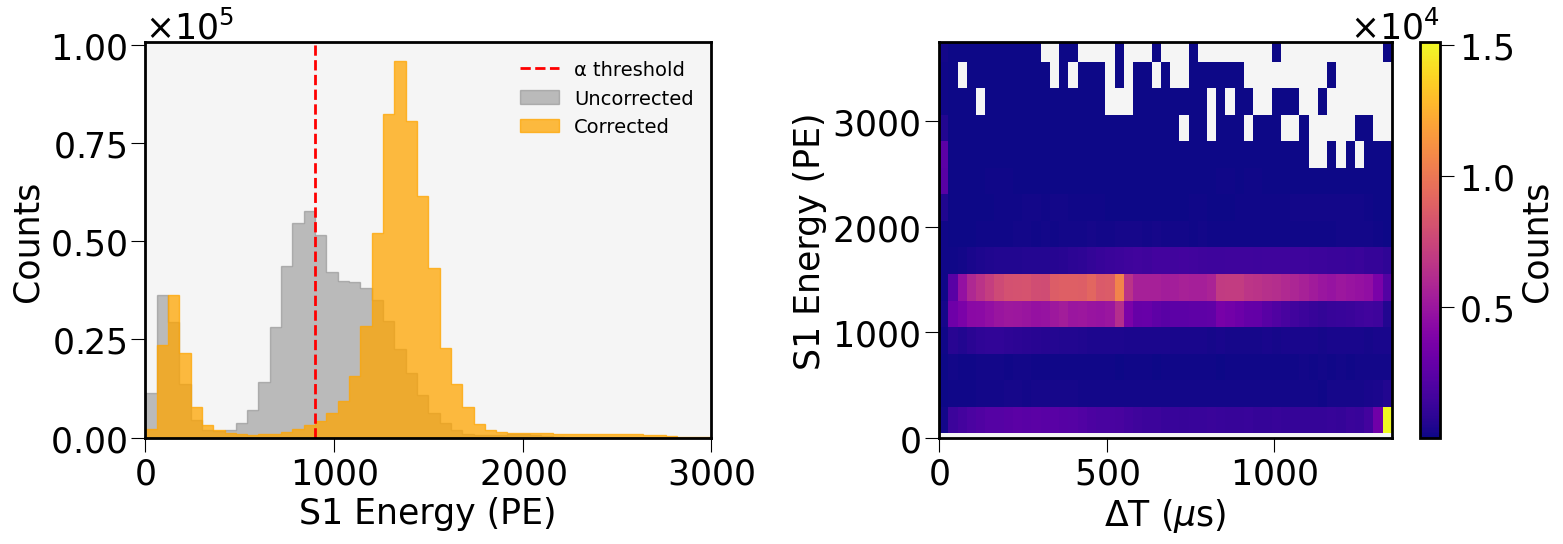

In [17]:
E1_min = 0; E1_max = 3e3

# Variables    
E1  = MERGED_DF['S1e']
E1c = MERGED_DF['S1e_corr']
DT  = MERGED_DF['DT']

print(f"DT  = [{DT.min():.2f}, {DT.max():.2f}] μs")
print(f"E1  = [{E1.min():.2f}, {E1.max():.2f}] PE")
print(f"E1c = [{E1c.min():.2f}, {E1c.max():.2f}] PE")

# Masking
mask = (MERGED_DF['DT'] > 0) & (MERGED_DF['DT'] <= DT_CATH)
E1_mask  = E1[mask]
E1c_mask = E1c[mask]
DT_mask  = DT[mask]

# 2D histogram: normalized by corrected DAQ data taking time
S1e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E1c_mask, x_bins=50, y_bins=100)                        
S1e_DT_map         = np.ma.masked_where(S1e_DT_map == 0, S1e_DT_map)

# ----- Plotting ----- #
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left
axes[0].hist(E1_mask, bins=50, range=(E1_min, E1_max), histtype='stepfilled', lw=1.0, color='grey', alpha=0.50, ec='grey', label='Uncorrected')
axes[0].hist(E1c_mask, bins=50, range=(E1_min, E1_max), histtype='stepfilled', lw=1.0, color='orange', alpha=0.75, ec='orange', label='Corrected')
axes[0].axvline(x=S1_ENERGY_THRESHOLD, color='red', ls='--', lw=2.0, label='α threshold')
axes[0].set_xlabel('S1 Energy (PE)')
axes[0].set_xlim(E1_min, E1_max)
axes[0].set_ylabel('Counts')
axes[0].legend(loc='upper right', fontsize=14, facecolor='none')
axes[0].set_facecolor('whitesmoke')

# Right
pcm = axes[1].pcolormesh(ex, ey, S1e_DT_map.T, cmap='plasma', shading='auto')
cbar = fig.colorbar(pcm, ax=axes[1], label='Counts')
axes[1].set_xlabel('$\Delta$T ($\mu$s)')
axes[1].set_xlim(0, DT_mask.max())
axes[1].set_ylim(E1_min, 1.25*E1_max)
axes[1].set_ylabel('S1 Energy (PE)')
axes[1].set_facecolor('whitesmoke')

plt.tight_layout()
plt.show()

# Tag Events

### By Particle

In [18]:
%%skip_if TYPE == 'mc'

MERGED_DF = crudo.dm.tag_particles( MERGED_DF
                                  , size_threshold      = SIZE_THRESHOLD
                                  , s1_energy_threshold = S1_ENERGY_THRESHOLD
                                  , event_column        = 'global_event' )

print(MERGED_DF.head())

   event  nS1  nS2  old_n_hits          time          S1e     S1e_corr    S1w  \
0   1058    1    1        8233  1.754042e+09  1348.162720  1338.559467  800.0   
1   2206    1    1         830  1.754042e+09    89.690819   106.070786  350.0   
2   3102    0    1         869  1.754042e+09          NaN          NaN    NaN   
3   5461    1    1        1380  1.754042e+09   902.388672  1378.194155  800.0   
4   6126    1    1         773  1.754042e+09  1024.439575  1390.200778  625.0   

          S1h        S1t  ...    X_max    Y_min    Y_max        Z_min  \
0  237.075485    49775.0  ...  490.025 -479.925  492.725  1165.845054   
1   13.100248   484750.0  ... -220.275 -155.875  -16.425   780.906971   
2         NaN        NaN  ...  351.075 -171.425  384.375   136.444451   
3  155.612564  1008000.0  ...  412.275 -402.675  461.625   338.059516   
4  171.154953   782325.0  ... -297.025 -294.825  -48.025   532.266397   

         Z_max       R_max  run_number  global_event           DT  particl

### By Detector Region

In [19]:
MERGED_DF = crudo.dm.tag_event_by_detector_region( MERGED_DF
                                                 , z_cut_low    = Z_LOW
                                                 , z_cut_high   = Z_UP
                                                 , r_cut_high   = R_UP
                                                 , event_column = 'global_event' )

print(MERGED_DF.head())

   event  nS1  nS2  old_n_hits          time          S1e     S1e_corr    S1w  \
0   1058    1    1        8233  1.754042e+09  1348.162720  1338.559467  800.0   
1   2206    1    1         830  1.754042e+09    89.690819   106.070786  350.0   
2   3102    0    1         869  1.754042e+09          NaN          NaN    NaN   
3   5461    1    1        1380  1.754042e+09   902.388672  1378.194155  800.0   
4   6126    1    1         773  1.754042e+09  1024.439575  1390.200778  625.0   

          S1h        S1t  ...    Y_min    Y_max        Z_min        Z_max  \
0  237.075485    49775.0  ... -479.925  492.725  1165.845054  1203.139853   
1   13.100248   484750.0  ... -155.875  -16.425   780.906971   818.263077   
2         NaN        NaN  ... -171.425  384.375   136.444451   145.976535   
3  155.612564  1008000.0  ... -402.675  461.625   338.059516   357.730589   
4  171.154953   782325.0  ... -294.825  -48.025   532.266397   555.681839   

        R_max  run_number  global_event           

# Output

In [21]:
MERGED_DF

,event,nS1,nS2,old_n_hits,time,S1e,S1e_corr,S1w,S1h,S1t,...,Y_min,Y_max,Z_min,Z_max,R_max,run_number,global_event,DT,particle,region
0,1058,1,1,8233,1.754042e+09,1348.162720,1338.559467,800.0,237.075485,49775.0,...,-479.925,492.725,1165.845054,1203.139853,494.279785,15625,0,1369.710875,alpha,cathode
1,2206,1,1,830,1.754042e+09,89.690819,106.070786,350.0,13.100248,484750.0,...,-155.875,-16.425,780.906971,818.263077,400.435964,15625,1,925.729875,electron,fiducial
2,3102,0,1,869,1.754042e+09,NaN,NaN,NaN,NaN,NaN,...,-171.425,384.375,136.444451,145.976535,572.328604,15625,2,NaN,electron,anode
3,5461,1,1,1380,1.754042e+09,902.388672,1378.194155,800.0,155.612564,1008000.0,...,-402.675,461.625,338.059516,357.730589,507.585595,15625,3,401.484875,alpha,tube
4,6126,1,1,773,1.754042e+09,1024.439575,1390.200778,625.0,171.154953,782325.0,...,-294.825,-48.025,532.266397,555.681839,488.325226,15625,4,627.154750,alpha,tube
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1026376,1789053,1,1,7630,1.759302e+09,1407.644653,1397.452557,650.0,251.366013,49450.0,...,-479.925,492.725,1163.695637,1204.315713,506.672815,15737,939941,1370.037875,alpha,cathode
1026377,1789270,1,1,8047,1.759302e+09,1378.959717,1368.765855,900.0,233.034393,49025.0,...,-479.925,492.725,1164.829003,1209.152468,500.123641,15737,939942,1370.461375,alpha,cathode
1026378,1790145,0,1,7346,1.759302e+09,NaN,NaN,NaN,NaN,NaN,...,-479.925,492.725,19.056382,63.463104,498.160472,15737,939943,NaN,alpha,anode
1026379,1790215,1,1,9115,1.759302e+09,1307.270386,1474.721202,675.0,222.353699,377450.0,...,-479.925,492.725,881.601513,915.386142,496.083225,15737,939944,1038.037375,alpha,tube


In [20]:
FINAL_DF = MERGED_DF[FINAL_COLS].copy()
FINAL_DF

KeyError: "['E_evt'] not in index"

In [27]:
FINAL_DF.to_hdf(MERGED_PATH, key='Events', mode='w', format='table')
print('Done!')

Done!


# Summary

So, this is basically the selection process I'll perform in different analyses.
<br>
But here, I just store the event counters for my summaries.

## Reconstructed

In [36]:
m_he_scale = HE_SCALE['m']
b_he_scale = HE_SCALE['b']

# --- Electron-like Cut --- #
if TYPE == 'data':
    FINAL_DF = FINAL_DF[FINAL_DF['particle'] == 'electron'].copy()
elif TYPE == 'mc':  
    pass    # In MC there are only electrons

# --- HE Scale --- #
FINAL_DF = crudo.ef.he_scale_converter(FINAL_DF, m_he_scale, b_he_scale, input_column='E_evt', output_column='E_final')
FINAL_DF = FINAL_DF[FINAL_DF['E_final'] >= TRG2_THRESHOLD].copy()

# Update summary
cut_counts = FINAL_DF.groupby(GROUPERS[0])['global_event'].nunique()
SUMMARY_DF['Reconstructed'] = SUMMARY_DF[GROUPERS[1]].map(cut_counts).fillna(0).astype(int)

## Selection

### Inclusive Electrons ($nS2=1$)

In [39]:
# --- nS2 = 1 Cut --- #
FINAL_DF = FINAL_DF[FINAL_DF['nS2'] == 1].copy()

# Update summary
cut_counts = FINAL_DF.groupby(GROUPERS[0])['global_event'].nunique()
SUMMARY_DF['Inclusive'] = SUMMARY_DF[GROUPERS[1]].map(cut_counts).fillna(0).astype(int)

### Fiducial Electrons

In [41]:
# --- Fiducial Volume Cut --- #
FINAL_DF = FINAL_DF[FINAL_DF['region'] == 'fiducial'].copy()

# Update summary
cut_counts = FINAL_DF.groupby(GROUPERS[0])['global_event'].nunique()
SUMMARY_DF['Fiducial'] = SUMMARY_DF[GROUPERS[1]].map(cut_counts).fillna(0).astype(int)

### Single Track: or cluster ;)

In [43]:
# --- Single Track Cut --- #
FINAL_DF = FINAL_DF[FINAL_DF['n_cluster'] == 1].copy()

# Update summary
cut_counts = FINAL_DF.groupby(GROUPERS[0])['global_event'].nunique()
SUMMARY_DF['Single_Track'] = SUMMARY_DF[GROUPERS[1]].map(cut_counts).fillna(0).astype(int)

## Update

In [48]:
SUMMARY_DF.to_csv(SUMM_PATH)
print('Done!')

Done!
